# HiST Benchmark (Strict Reproduction with Custom Data)

This notebook reproduces the HiST pipeline using your dataset and gene list, while keeping outputs aligned with the 01_* benchmark style.


In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import scanpy as sc
from PIL import Image

# Optional OpenSlide
try:
    import openslide
    HAS_OPENSLIDE = True
except ImportError:
    HAS_OPENSLIDE = False
    print("OpenSlide not found, using PIL fallback (may be slow).")

ROOT = Path(os.environ.get("MORPHO_VC_ROOT", "../")).expanduser().resolve()
HIST_SRC = ROOT / "benchmark" / "HiST" / "src"
sys.path.append(str(HIST_SRC))

from util.seed import seed_torch
from FeatureExtraction.feature import extract_features, load_features
from PredictionModule.model import CMUNet
from PredictionModule.metrics import calculate_correlations
from util.predict import VisualizeGenePreprocess, plot_gene_image

seed_torch(42)

# IDs
train_ids = ["INT25", "INT26"]
val_ids = ["INT27"]
test_ids = ["INT28"]
all_ids = train_ids + val_ids + test_ids

# Paths
result_dir = ROOT / "benchmark" / "results" / "hist"
result_dir.mkdir(parents=True, exist_ok=True)

hist_input_dir = result_dir / "hist_input"
tissue_pos_dir = hist_input_dir / "tissue_positions_list"
scale_factor_dir = hist_input_dir / "scale_factor"
gene_matrix_dir = hist_input_dir / "geneMatrix" / "normed"
tile_dir = hist_input_dir / "tile"
feature_dir = hist_input_dir / "features"

for d in [tissue_pos_dir, scale_factor_dir, gene_matrix_dir, tile_dir, feature_dir]:
    d.mkdir(parents=True, exist_ok=True)

spatial_dir = ROOT / "data" / "spatial_data"
wsi_dir = ROOT / "data" / "hest_data" / "wsis"
common_gene_path = spatial_dir / "common_genes.txt"

ctranspath_weights = ROOT / "benchmark" / "HiST" / "resource" / "ctranspath.pth"
print("Result dir:", result_dir)


c:\ProgramData\anaconda3\envs\scellst_bench\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


Result dir: E:\Morpho-FM\benchmark\results\hist


In [2]:
TILE_ROWNUM = 80
TILE_COLNUM = 64
ROW_PAD = (TILE_ROWNUM - 78) // 2
COL_PAD = (TILE_COLNUM - 64) // 2

import scipy.sparse as sp

# ===== Helpers =====

def read_gene_list(path: Path):
    genes = path.read_text(encoding="utf-8").splitlines()
    return [g.strip() for g in genes if g.strip()]


def get_scalefactors(adata):
    sf = None
    if "spatial" in adata.uns:
        spatial = adata.uns["spatial"]
        if isinstance(spatial, dict) and len(spatial) > 0:
            entry = next(iter(spatial.values()))
            sf = entry.get("scalefactors", None)
    return sf or {}


def write_tissue_positions_and_scale(adata, sid: str):
    df = pd.DataFrame({
        "barcode": adata.obs_names,
        "in_tissue": adata.obs["in_tissue"].astype(int).values,
        "array_row": adata.obs["array_row"].astype(int).values,
        "array_col": adata.obs["array_col"].astype(int).values,
        "imagerow": adata.obs["pxl_row_in_fullres"].astype(float).values,
        "imagecol": adata.obs["pxl_col_in_fullres"].astype(float).values,
    })
    df.to_csv(tissue_pos_dir / f"{sid}.csv", index=False)

    sf = get_scalefactors(adata)
    spot = float(sf.get("spot_diameter_fullres", 1.0))
    fiducial = float(sf.get("fiducial_diameter_fullres", spot))
    hires = float(sf.get("tissue_hires_scalef", 1.0))
    lowres = float(sf.get("tissue_lowres_scalef", sf.get("tissue_downscaled_fullres_scalef", 1.0)))

    scale_df = pd.DataFrame({
        "spot": [spot],
        "fiducial": [fiducial],
        "hires": [hires],
        "lowres": [lowres],
    })
    scale_df.to_csv(scale_factor_dir / f"{sid}.csv", index=False)


def build_gene_matrix(adata, genes, sid: str = ""):
    # Ensure genes exist
    missing = [g for g in genes if g not in adata.var_names]
    if missing:
        raise ValueError(f"Missing genes in {sid}: {len(missing)}")

    ad = adata[:, genes].copy()
    # HiST uses LogNormalize (target_sum=1e4) + log1p
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

    X = ad.X
    if sp.issparse(X):
        X = X.toarray()
    X = X.astype(np.float32)

    rows = ad.obs["array_row"].to_numpy().astype(int)
    cols = ad.obs["array_col"].to_numpy().astype(int)

    # HiST R create_geneMatrix mapping
    row_idx = rows + ROW_PAD  # +2 top padding (0-based)
    col_idx = np.where(rows % 2 == 0, cols // 2, (cols - 1) // 2)

    if row_idx.min() < 0 or row_idx.max() >= TILE_ROWNUM or col_idx.min() < 0 or col_idx.max() >= TILE_COLNUM:
        raise ValueError("Grid index out of bounds. Check array_row/array_col ranges.")

    grid = np.zeros((80, 64, len(genes)), dtype=np.float32)
    grid[row_idx, col_idx, :] = X
    return grid


def tile_fullres_wsi(sid: str, padding: bool = True, tile_rownum: int = 80, tile_colnum: int = 64):
    pos_path = tissue_pos_dir / f"{sid}.csv"
    scale_path = scale_factor_dir / f"{sid}.csv"
    out_path = tile_dir / sid
    out_path.mkdir(parents=True, exist_ok=True)

    if any(out_path.glob("*.jpeg")):
        print(f"Tiles exist for {sid}, skip tiling.")
        return

    pos = pd.read_csv(pos_path)
    scale_df = pd.read_csv(scale_path)
    crop_size = int(round(scale_df.iloc[0, 1]))  # fiducial

    # locate WSI
    wsi_files = list(wsi_dir.glob(f"{sid}.*"))
    if len(wsi_files) == 0:
        raise FileNotFoundError(f"WSI not found for {sid} in {wsi_dir}")
    wsi_path = wsi_files[0]

    Image.MAX_IMAGE_PIXELS = None
    if HAS_OPENSLIDE:
        slide = openslide.OpenSlide(str(wsi_path))
    else:
        slide = Image.open(wsi_path)

    total = tile_rownum * tile_colnum if padding else len(pos)
    with tqdm(total=total, desc=f"Tiling {sid}") as pbar:
        for _, row in pos.iterrows():
            array_row = int(row["array_row"])
            array_col = int(row["array_col"])

            if array_row % 2 == 0:
                array_col = array_col // 2
            else:
                array_col = (array_col - 1) // 2

            if padding:
                array_row = array_row + ROW_PAD
                array_col = array_col + COL_PAD

            imagerow = float(row["imagerow"])
            imagecol = float(row["imagecol"])

            left = int(round(imagecol - crop_size / 2))
            top = int(round(imagerow - crop_size / 2))

            if HAS_OPENSLIDE:
                patch = slide.read_region((left, top), 0, (crop_size, crop_size)).convert("RGB")
            else:
                patch = slide.crop((left, top, left + crop_size, top + crop_size)).convert("RGB")

            tile_name = f"{array_row}-{array_col}-{crop_size}.jpeg"
            patch.save(out_path / tile_name, "JPEG")
            pbar.update(1)

        if padding:
            for r in range(tile_rownum):
                for c in range(tile_colnum):
                    filename = f"{r}-{c}-{crop_size}.jpeg"
                    output_path = out_path / filename
                    if not output_path.exists():
                        blank = Image.new("RGB", (crop_size, crop_size), (255, 255, 255))
                        blank.save(output_path, "JPEG")
                        pbar.update(1)


def ensure_features(tile_path: Path, slide_ids: list, feature_path: Path):
    # Use POSIX-style paths for HiST feature extractor (Windows-safe)
    tile_path_posix = tile_path.as_posix()
    feature_path_posix = feature_path.as_posix()
    if feature_path.exists():
        return load_features(feature_path_posix)
    return extract_features(
        tile_path=tile_path_posix,
        img_ids=slide_ids,
        model_weight_path=str(ctranspath_weights),
        save=True,
        seed=42,
        file=feature_path_posix
    )
class GeneDatasetNPY(Dataset):
    def __init__(self, img_ids, tensor_lists, gene_dir, num_genes):
        self.img_ids = img_ids
        self.tensor_lists = tensor_lists
        self.gene_dir = Path(gene_dir)
        self.num_genes = num_genes

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img = self.tensor_lists[idx]
        img = img.view(80, 64, 768).permute(2, 0, 1)

        img_id = self.img_ids[idx]
        gene_matrix = np.load(self.gene_dir / f"{img_id}.npy").astype("float32")
        # (80, 64, G) -> (G, 80, 64)
        gene_matrix = gene_matrix.transpose(2, 0, 1)

        return img, torch.from_numpy(gene_matrix), {"img_id": img_id}


In [3]:
# ===== Step 1: Build HiST inputs (tissue_positions, scale_factors, geneMatrix) =====

genes = read_gene_list(common_gene_path)
print(f"Genes: {len(genes)}")

for sid in all_ids:
    print(f"Preparing inputs for {sid}...")
    adata = sc.read_h5ad(spatial_dir / f"{sid}.h5ad")

    # positions + scale factors
    write_tissue_positions_and_scale(adata, sid)

    # geneMatrix (HiST mapping)
    grid = build_gene_matrix(adata, genes, sid=sid)
    np.save(gene_matrix_dir / f"{sid}.npy", grid)

print("Input preparation done.")


Genes: 17512
Preparing inputs for INT25...
Preparing inputs for INT26...
Preparing inputs for INT27...
Preparing inputs for INT28...
Input preparation done.


In [4]:
# ===== Step 2: Tiling + Feature Extraction (HiST) =====

for sid in all_ids:
    tile_fullres_wsi(sid)

feature_path = feature_dir / "all_sample_features.pkl"
all_sample_features = ensure_features(tile_dir, all_ids, feature_path)

print("Feature extraction done.")


Tiling INT28: 100%|██████████| 5120/5120 [00:09<00:00, 526.02it/s] 
c:\ProgramData\anaconda3\envs\scellst_bench\lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
INT28 Feature Extracting: 100%|██████████ [ time left: 00:00 ]

Extracting Feature Time Cost: 1.045004 min
Feature extraction done.


In [5]:
# ===== Step 3: Train HiST GeneSolver (train/val split) =====

# Map features to IDs
feature_map = {sid: feat for sid, feat in zip(all_ids, all_sample_features)}
train_feats = [feature_map[sid] for sid in train_ids]
val_feats = [feature_map[sid] for sid in val_ids]
test_feats = [feature_map[sid] for sid in test_ids]

train_ds = GeneDatasetNPY(train_ids, train_feats, gene_matrix_dir, len(genes))
val_ds = GeneDatasetNPY(val_ids, val_feats, gene_matrix_dir, len(genes))
test_ds = GeneDatasetNPY(test_ids, test_feats, gene_matrix_dir, len(genes))

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

from PredictionModule.solver import GeneSolver

model_dir = result_dir / "models"
model_dir.mkdir(parents=True, exist_ok=True)
val_id = val_ids[0]

best_model_path = model_dir / "best_model" / f"{val_id}_best_model.pth"

if not best_model_path.exists():
    print("Training HiST gene model...")
    solver = GeneSolver(seed=42, img_ch=768, epochs=200, lr=0.001, weight_decay=1e-4, verbose=True)
    _ = solver._fit_loo(train_loader, val_loader, genes, val_id, str(model_dir), use_best=True)
else:
    print(f"Using existing checkpoint: {best_model_path}")


Training HiST gene model...
Epoch [1/200]
loss 0.3855 - val_loss 0.2525 - mae 0.4340 - val_mae 0.2667 - rmse 0.6172 - val_rmse 0.5025
Epoch1 Total Time Cost: 0.027633 min
Epoch [2/200]
loss 0.2762 - val_loss 0.2486 - mae 0.3096 - val_mae 0.2667 - rmse 0.5162 - val_rmse 0.4986
Epoch2 Total Time Cost: 0.049733 min
Epoch [3/200]
loss 0.2293 - val_loss 0.2402 - mae 0.2546 - val_mae 0.2641 - rmse 0.4829 - val_rmse 0.4901
Epoch3 Total Time Cost: 0.072235 min
Epoch [4/200]
loss 0.2142 - val_loss 0.2287 - mae 0.2293 - val_mae 0.2578 - rmse 0.4500 - val_rmse 0.4782
Epoch4 Total Time Cost: 0.094026 min
Epoch [5/200]
loss 0.2028 - val_loss 0.2156 - mae 0.2207 - val_mae 0.2512 - rmse 0.4373 - val_rmse 0.4643
Epoch5 Total Time Cost: 0.116483 min
Epoch [6/200]
loss 0.1899 - val_loss 0.2005 - mae 0.2158 - val_mae 0.2444 - rmse 0.4226 - val_rmse 0.4477
Epoch6 Total Time Cost: 0.138121 min
Epoch [7/200]
loss 0.1763 - val_loss 0.1846 - mae 0.2126 - val_mae 0.2363 - rmse 0.4042 - val_rmse 0.4296
Epoch7 T

In [6]:
# ===== Step 4: Evaluation + Save pred_bag/true_bag + metrics =====

# Load best model
model = CMUNet(img_ch=768, output_ch=len(genes), l=7, k=7).cuda()
model.load_state_dict(torch.load(best_model_path))
model.eval()

# Correlations (HiST style)
cor_dir = result_dir / "correlations"
cor_dir.mkdir(parents=True, exist_ok=True)
calculate_correlations(genes, test_ids[0], test_loader, model, str(cor_dir))

# Predict maps
pred_maps = {}
true_maps = {}

with torch.no_grad():
    for img, gene_matrix, meta in test_loader:
        sid = meta["img_id"][0] if isinstance(meta["img_id"], (list, tuple)) else meta["img_id"]
        img = img.cuda()
        pred = model(img).cpu().numpy()[0]  # (G, 80, 64)
        true = gene_matrix.numpy()[0]
        pred_maps[sid] = pred
        true_maps[sid] = true

# Build pred_bag/true_bag using in_tissue spots
pred_bag_list = []
true_bag_list = []

for sid in test_ids:
    adata = sc.read_h5ad(spatial_dir / f"{sid}.h5ad")
    obs = adata.obs
    mask = obs["in_tissue"].to_numpy().astype(bool)
    rows = obs["array_row"].to_numpy().astype(int)[mask]
    cols = obs["array_col"].to_numpy().astype(int)[mask]

    row_idx = rows + ROW_PAD
    col_idx = np.where(rows % 2 == 0, cols // 2, (cols - 1) // 2)

    pred_map = pred_maps[sid]
    true_map = true_maps[sid]

    pred_vals = pred_map[:, row_idx, col_idx].T
    true_vals = true_map[:, row_idx, col_idx].T

    pred_bag_list.append(pred_vals)
    true_bag_list.append(true_vals)

pred_bag = np.concatenate(pred_bag_list, axis=0)
true_bag = np.concatenate(true_bag_list, axis=0)

print("Prediction Shape:", pred_bag.shape)

# Metrics (01 style)

def pearson_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if a.size == 0 or b.size == 0:
        return np.nan
    if np.all(a == a[0]) or np.all(b == b[0]):
        return np.nan
    a = a - a.mean()
    b = b - b.mean()
    denom = np.sqrt((a * a).sum()) * np.sqrt((b * b).sum())
    if denom == 0:
        return np.nan
    return float((a * b).sum() / denom)

mae = float(np.mean(np.abs(pred_bag - true_bag)))
rmse = float(np.sqrt(np.mean((pred_bag - true_bag) ** 2)))

# Gene-wise Pearson
corrs = []
for i in range(pred_bag.shape[1]):
    corrs.append(pearson_corr(pred_bag[:, i], true_bag[:, i]))

valid = [(i, c) for i, c in enumerate(corrs) if not np.isnan(c)]
mean_pearson = float(np.mean([c for _, c in valid])) if valid else float("nan")

best_gene_idx, best_gene_corr = max(valid, key=lambda x: x[1]) if valid else (None, None)
best_gene_name = genes[best_gene_idx] if best_gene_idx is not None else "NA"

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Mean Pearson (gene-wise): {mean_pearson:.4f}")
print(f"Best Gene: {best_gene_name} (Pearson={best_gene_corr:.4f})")

# Save results
np.save(result_dir / "pred_bag.npy", pred_bag)
np.save(result_dir / "true_bag.npy", true_bag)

metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "Mean_Pearson": mean_pearson,
    "Best_Gene": best_gene_name,
    "Best_Pearson": float(best_gene_corr) if best_gene_corr is not None else None,
}
with open(result_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("Saved pred_bag/true_bag/metrics.json")


E:\Morpho-FM\benchmark\HiST\src\PredictionModule\metrics.py:136: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_cor, pearson_pvalue = pearsonr(tensor1_flat, tensor2_flat)
E:\Morpho-FM\benchmark\HiST\src\PredictionModule\metrics.py:137: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_cor, spearman_pvalue = spearmanr(tensor1_flat, tensor2_flat)


Prediction Shape: (3990, 17512)
MAE: 0.1999
RMSE: 0.3689
Mean Pearson (gene-wise): 0.0770
Best Gene: AZGP1 (Pearson=0.7024)
Saved pred_bag/true_bag/metrics.json


Saved figure to: E:\Morpho-FM\benchmark\results\hist\top4_genes_vis.png


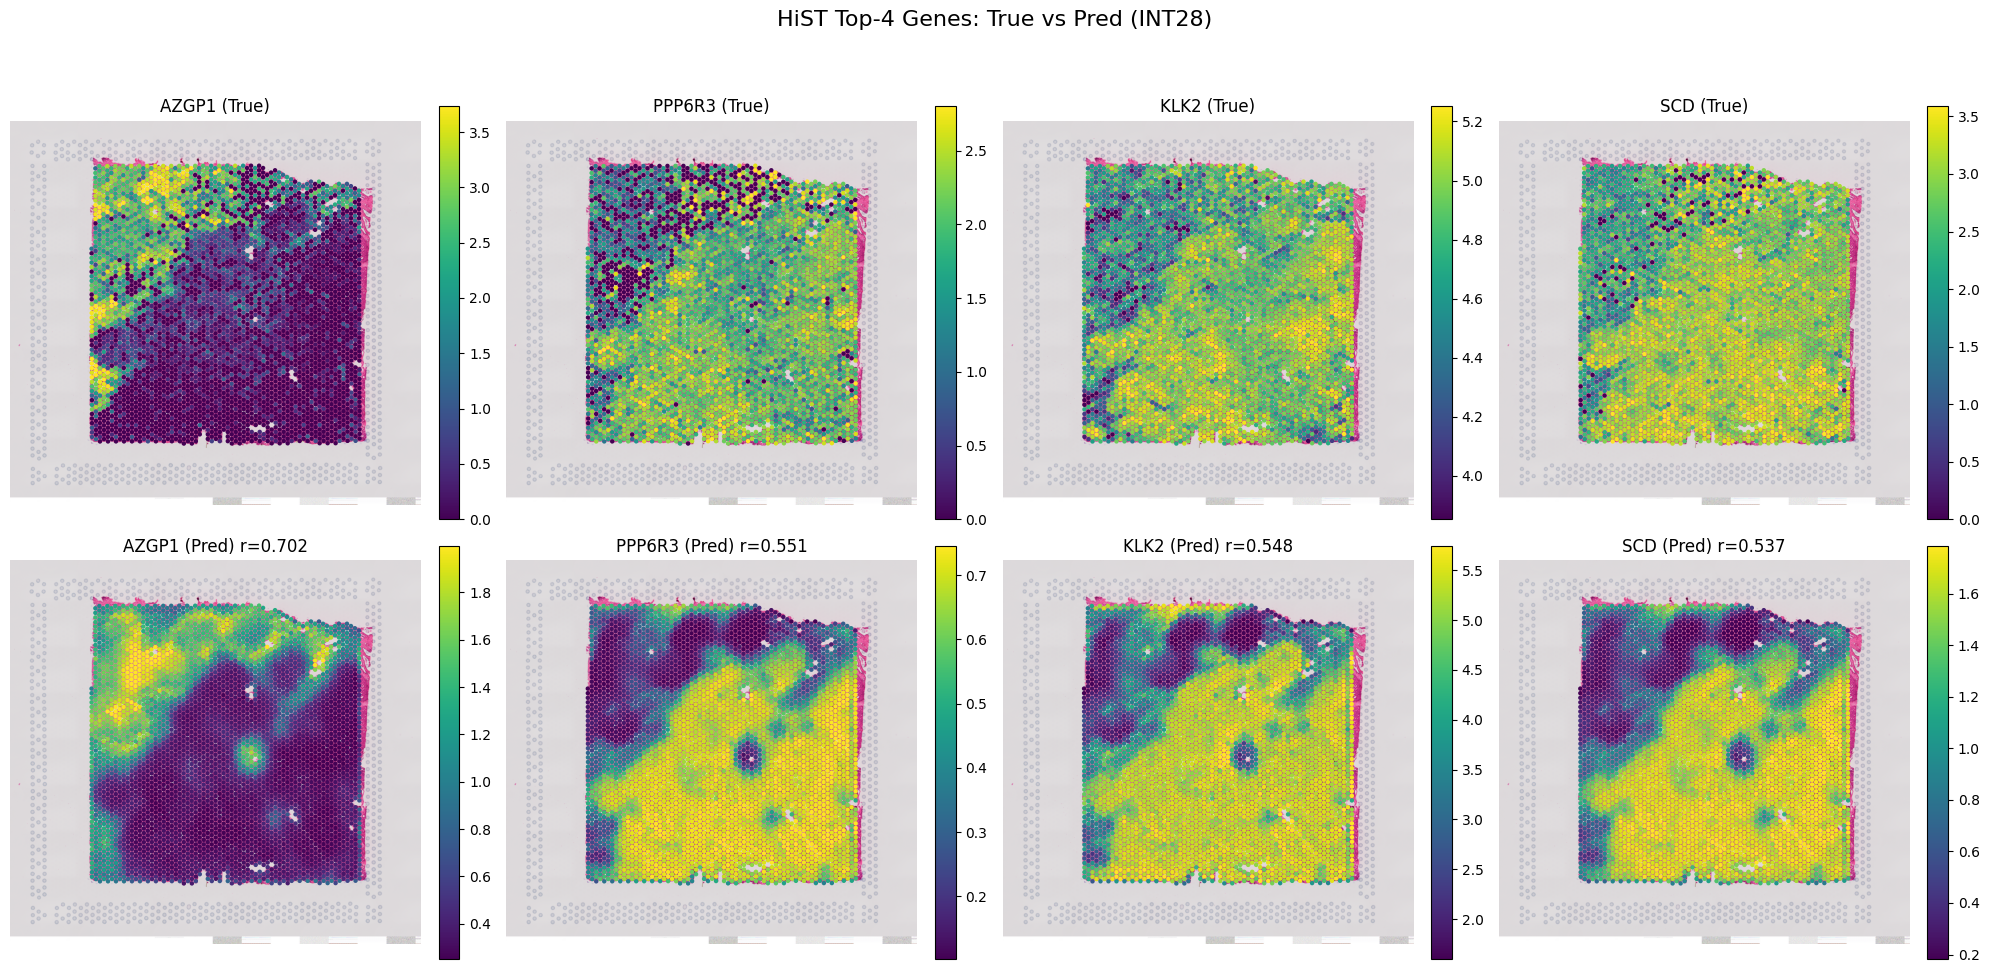

In [7]:
import matplotlib.pyplot as plt
# ===== Step 5: Visualization (01-style layout with HiST coords) =====

def robust_vmin_vmax(arr, p_low=1, p_high=99):
    a = np.asarray(arr, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return 0.0, 1.0
    vmin, vmax = np.percentile(a, [p_low, p_high])
    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmin == vmax):
        vmin, vmax = float(np.min(a)), float(np.max(a))
        if vmin == vmax:
            eps = 1e-6 if vmin == 0 else abs(vmin) * 1e-6
            vmin, vmax = vmin - eps, vmax + eps
    return vmin, vmax

VIS_ID = test_ids[0]

# Load tissue positions (fullres pixel coords)
pos = pd.read_csv(tissue_pos_dir / f"{VIS_ID}.csv")
mask = pos["in_tissue"].astype(bool).values
x = pos["imagecol"].values[mask]
y = pos["imagerow"].values[mask]

rows = pos["array_row"].astype(int).values[mask]
cols = pos["array_col"].astype(int).values[mask]
row_idx = rows + ROW_PAD
col_idx = np.where(rows % 2 == 0, cols // 2, (cols - 1) // 2)

pred_map = pred_maps[VIS_ID]
true_map = true_maps[VIS_ID]

pred_vals = pred_map[:, row_idx, col_idx].T
true_vals = true_map[:, row_idx, col_idx].T

# Top-4 genes by Pearson
n_show = min(4, len(valid))
top4_indices = [idx for idx, _ in sorted(valid, key=lambda t: t[1], reverse=True)[:n_show]]

# Background WSI
wsi_files = list(wsi_dir.glob(f"{VIS_ID}.*"))
if len(wsi_files) == 0:
    raise FileNotFoundError(f"WSI not found for {VIS_ID}")

wsi_path = wsi_files[0]
if HAS_OPENSLIDE:
    slide = openslide.OpenSlide(str(wsi_path))
    w0, h0 = slide.dimensions
    thumb_w = 2000
    scale = thumb_w / w0
    thumb_h = int(h0 * scale)
    bg_img = slide.get_thumbnail((thumb_w, thumb_h))
else:
    bg_img = Image.open(wsi_path)
    w0, h0 = bg_img.size

bg_extent = (0, w0, h0, 0)

fig, axes = plt.subplots(2, n_show, figsize=(5 * n_show, 10))
if n_show == 1:
    axes = np.array(axes).reshape(2, 1)

fig.suptitle(f"HiST Top-{n_show} Genes: True vs Pred ({VIS_ID})", fontsize=16, y=0.98)

for i, gene_idx in enumerate(top4_indices):
    gene_name = genes[gene_idx]
    corr = corrs[gene_idx]

    gt = true_vals[:, gene_idx]
    pr = pred_vals[:, gene_idx]

    vmin_gt, vmax_gt = robust_vmin_vmax(gt)
    vmin_pr, vmax_pr = robust_vmin_vmax(pr)

    # True
    ax_gt = axes[0, i]
    ax_gt.imshow(bg_img, extent=bg_extent)
    sc_gt = ax_gt.scatter(x, y, c=gt, cmap="viridis", s=10, vmin=vmin_gt, vmax=vmax_gt, edgecolors="none")
    ax_gt.set_title(f"{gene_name} (True)")
    ax_gt.axis("off")
    plt.colorbar(sc_gt, ax=ax_gt, fraction=0.046, pad=0.04)

    # Pred
    ax_pr = axes[1, i]
    ax_pr.imshow(bg_img, extent=bg_extent)
    sc_pr = ax_pr.scatter(x, y, c=pr, cmap="viridis", s=10, vmin=vmin_pr, vmax=vmax_pr, edgecolors="none")
    ax_pr.set_title(f"{gene_name} (Pred) r={corr:.3f}")
    ax_pr.axis("off")
    plt.colorbar(sc_pr, ax=ax_pr, fraction=0.046, pad=0.04)

plt.tight_layout(rect=[0, 0, 1, 0.95])
out_path = result_dir / "top4_genes_vis.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()
